# FOMO Object Detection for ESP32-CAM

**Faster Objects, More Objects (FOMO)** — a lightweight centroid-based object detector
designed for microcontrollers.

## Architecture Overview

Unlike traditional detectors (YOLO, SSD) that predict bounding boxes, FOMO:
1. Divides the image into a grid (e.g., 12×12 for 96×96 input)
2. Each grid cell predicts **which class** is centered there (or background)
3. No bounding box regression → drastically fewer parameters
4. Uses a truncated MobileNetV2 backbone (stride-8) for features

This makes it ideal for ESP32-CAM with ~4MB PSRAM and ~520KB SRAM.

### Target Classes
| Index | Class | COCO ID | Purpose |
|-------|-------|---------|----------|
| 0 | background | — | No object |
| 1 | person | 1 | Interaction target |
| 2 | sports_ball | 37 | Fetch/track target |
| 3 | chair | 62 | Obstacle avoidance |
| 4 | couch | 63 | Obstacle avoidance |
| 5 | dining_table | 67 | Obstacle avoidance |

### Memory Budget
- **Model size target**: < 250 KB (int8 quantized TFLite)
- **Input tensor**: 96×96×3 = 27,648 bytes
- **Output tensor**: 12×12×6 = 864 bytes
- **Arena (TFLite Micro)**: ~300 KB (fits in PSRAM)

## 1. Environment Setup

In [1]:
# Install dependencies
!pip install torch torchvision albumentations pycocotools matplotlib numpy onnx ai-edge-torch pandas
# For COCO dataset download:
!pip install fiftyone  # (optional, or download manually)

INFO: pip is looking at multiple versions of litert-torch to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of ai-edge-torch to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of ai-edge-torch to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 867.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.7/124.7 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.5/170.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.9/522.9 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.7/215.7 kB 24.5 MB

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 108.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.8/112.8 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 120.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.4/316.4 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.5/934.5 kB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 18.1 MB/s eta

In [88]:
import os
import json
import math
import random
from pathlib import Path
from collections import defaultdict
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

import albumentations as A
from albumentations.pytorch import ToTensorV2
from pycocotools.coco import COCO

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


## 2. Configuration

In [90]:
ENVIRONMENT = "local"

match ENVIRONMENT:
    case "colab":
        COCO_ROOT = Path('/content/coco')
        NUM_WORKERS = 2
        BATCH_SIZE = 128
    case "local":
        COCO_ROOT = Path('./datasets/coco')
        NUM_WORKERS = 4
        BATCH_SIZE = 64

In [133]:
# ── Model / training config ──────────────────────────────────────────────
INPUT_SIZE     = 192        # 96x96 pixels — fits ESP32 memory budget
GRID_SIZE      = 24        # INPUT_SIZE / stride(8) = 12
CELL_SIZE      = INPUT_SIZE // GRID_SIZE  # 8 pixels per cell
NUM_CLASSES    = 6         # background + 5 object classes
LEARNING_RATE  = 1e-3
NUM_EPOCHS     = 30
WEIGHT_DECAY   = 1e-4
MNV2_WIDTH_MULT     = 0.5   # MobileNetV2 width multiplier
MNV2_ROUND_NEAREST = 8      # MobileNetV2 round channels to nearest

# ── COCO class mapping ───────────────────────────────────────────────────
# Maps COCO category IDs → our internal class indices (1-indexed, 0=background)
COCO_TO_FOMO = {
    1:  1,   # person
    37: 2,   # sports_ball
    62: 3,   # chair
    63: 4,   # couch
    67: 5,   # dining_table
}
FOMO_CLASS_NAMES = ['background', 'person', 'sports_ball', 'chair', 'couch', 'dining_table']
TARGET_COCO_IDS = list(COCO_TO_FOMO.keys())

# ── Dataset paths ────────────────────────────────────────────────────────
COCO_TRAIN_IMGS = COCO_ROOT / 'train2017'
COCO_VAL_IMGS   = COCO_ROOT / 'val2017'
COCO_TRAIN_ANN  = COCO_ROOT / 'annotations' / 'instances_train2017.json'
COCO_VAL_ANN    = COCO_ROOT / 'annotations' / 'instances_val2017.json'

# ── Output paths ─────────────────────────────────────────────────────────
OUTPUT_DIR = Path('./output')
OUTPUT_DIR.mkdir(exist_ok=True)

print(f'Grid: {GRID_SIZE}x{GRID_SIZE} ({GRID_SIZE**2} cells)')
print(f'Each cell covers {CELL_SIZE}x{CELL_SIZE} pixels')
print(f'Classes: {FOMO_CLASS_NAMES}')

Grid: 24x24 (576 cells)
Each cell covers 8x8 pixels
Classes: ['background', 'person', 'sports_ball', 'chair', 'couch', 'dining_table']


## 3. Download & Filter COCO Dataset

We only need images that contain at least one of our target classes.
This reduces the dataset from ~118K to ~30K images.

In [5]:
%%bash
# Download COCO 2017 if not present (this is ~20 GB total)
# Uncomment the lines below if you need to download

mkdir -p coco && cd coco

# Train images
wget -q http://images.cocodataset.org/zips/train2017.zip && unzip -q train2017.zip

# Val images
wget -q http://images.cocodataset.org/zips/val2017.zip && unzip -q val2017.zip

# Annotations
wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip && unzip -q annotations_trainval2017.zip

echo "COCO directory contents:"
ls -la

COCO directory contents:
total 19931252
drwxr-xr-x 5 root root        4096 Mar 18 17:02 .
drwxr-xr-x 1 root root        4096 Mar 18 16:48 ..
drwxr-xr-x 2 root root        4096 Mar 18 17:02 annotations
-rw-r--r-- 1 root root   252907541 Jul 10  2018 annotations_trainval2017.zip
drwxrwxr-x 2 root root     4038656 Aug 31  2017 train2017
-rw-r--r-- 1 root root 19336861798 Jul 11  2018 train2017.zip
drwxrwxr-x 2 root root      167936 Aug 31  2017 val2017
-rw-r--r-- 1 root root   815585330 Jul 11  2018 val2017.zip


In [35]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [37]:
!mv /content/coco/*.zip /content/drive/MyDrive/datasets/coco

In [38]:
drive.flush_and_unmount()

In [134]:
def load_filtered_coco(annotation_path, target_cat_ids):
    """
    Load COCO annotations, keeping only images that contain
    at least one annotation from our target classes.

    Returns:
        coco: COCO API object
        image_ids: list of filtered image IDs
    """
    coco = COCO(str(annotation_path))

    # Collect image IDs that have at least one target annotation
    image_ids = set()
    for cat_id in target_cat_ids:
        image_ids.update(coco.getImgIds(catIds=[cat_id]))
    image_ids = sorted(image_ids)

    # Count per class
    class_counts = defaultdict(int)
    for img_id in image_ids:
        ann_ids = coco.getAnnIds(imgIds=img_id, catIds=target_cat_ids, iscrowd=False)
        for ann in coco.loadAnns(ann_ids):
            if ann['category_id'] in target_cat_ids:
                class_counts[ann['category_id']] += 1

    print(f'Filtered to {len(image_ids)} images')
    for cat_id, count in sorted(class_counts.items()):
        cat_name = coco.loadCats(cat_id)[0]['name']
        print(f'  {cat_name} (id={cat_id}): {count} annotations')

    return coco, image_ids

print('Loading training set...')
coco_train, train_ids = load_filtered_coco(COCO_TRAIN_ANN, TARGET_COCO_IDS)

print('\nLoading validation set...')
coco_val, val_ids = load_filtered_coco(COCO_VAL_ANN, TARGET_COCO_IDS)

Loading training set...
loading annotations into memory...
Done (t=5.15s)
creating index...
index created!
Filtered to 73948 images
  person (id=1): 257253 annotations
  sports ball (id=37): 6299 annotations
  chair (id=62): 38073 annotations
  couch (id=63): 5779 annotations
  dining table (id=67): 15695 annotations

Loading validation set...
loading annotations into memory...
Done (t=0.25s)
creating index...
index created!
Filtered to 3114 images
  person (id=1): 10777 annotations
  sports ball (id=37): 260 annotations
  chair (id=62): 1771 annotations
  couch (id=63): 261 annotations
  dining table (id=67): 695 annotations


## 4. Data Augmentation Pipeline

The OV2640 on ESP32-CAM produces noisy, low-dynamic-range images.
We simulate this during training so the model is robust to real-world input.

**Key augmentations**:
- `GaussNoise(var_limit=(100,500))` — simulates sensor noise
- `Blur(blur_limit=3)` — simulates motion blur / out-of-focus
- `RandomBrightnessContrast` — accounts for varying lighting
- `HueSaturationValue` — handles color cast from the sensor

In [135]:
# ── Training augmentations (simulate ESP32-CAM sensor degradation) ────────
train_transform = A.Compose([
    A.Resize(INPUT_SIZE, INPUT_SIZE),
    A.HorizontalFlip(p=0.5),
    #A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
    # A.GaussNoise(std_range=(0.05,0.2), p=0.2),  # Crucial for ESP32 sensors, expensive though
    #A.Blur(blur_limit=3, p=0.15),                # Motion / focus blur, expensive though
    #A.HueSaturationValue(
    #    hue_shift_limit=10,
    #    sat_shift_limit=20,
    #    val_shift_limit=20,
    #    p=0.3
    #),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], bbox_params=A.BboxParams(
    format='coco',                   # [x_min, y_min, width, height]
    label_fields=['category_ids'],
    min_area=16,                     # Drop tiny boxes post-resize
    min_visibility=0.2,
))

# ── Validation transform (no augmentation, just resize + normalize) ───────
val_transform = A.Compose([
    A.Resize(INPUT_SIZE, INPUT_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], bbox_params=A.BboxParams(
    format='coco',
    label_fields=['category_ids'],
    min_area=16,
    min_visibility=0.2,
))

print('Augmentation pipelines ready.')

Augmentation pipelines ready.


## 5. FOMO Dataset: Bounding Boxes → Centroid Grid

The key insight of FOMO: instead of predicting bounding boxes, we convert
each annotation into a **centroid on a grid**.

```
Image (96x96)          Grid (12x12)
┌──────────────┐       ┌─┬─┬─┬─┬─┬─┬─┬─┬─┬─┬─┬─┐
│              │       │0│0│0│0│0│0│0│0│0│0│0│0│
│   ┌──┐       │       ├─┼─┼─┼─┼─┼─┼─┼─┼─┼─┼─┼─┤
│   │🏀│       │  →    │0│0│2│0│0│0│0│0│0│0│0│0│  ← ball centroid
│   └──┘       │       ├─┼─┼─┼─┼─┼─┼─┼─┼─┼─┼─┼─┤
│        ┌──┐  │       │0│0│0│0│0│0│0│0│0│0│0│0│
│        │🧑│  │       ├─┼─┼─┼─┼─┼─┼─┼─┼─┼─┼─┼─┤
│        └──┘  │       │0│0│0│0│0│0│0│1│0│0│0│0│  ← person centroid
└──────────────┘       └─┴─┴─┴─┴─┴─┴─┴─┴─┴─┴─┴─┘
```

Each grid cell = 8×8 pixels. If multiple objects land in the same cell,
the last one wins (rare at this resolution).

In [136]:
class FOMODataset(Dataset):
    """
    Converts COCO annotations into FOMO centroid-grid targets.

    For each image:
      - Loads image + bboxes for our target classes
      - Applies augmentations (which also transform bboxes)
      - Converts each bbox centroid to a grid cell assignment
      - Returns image tensor [3, 96, 96] and target grid [12, 12]
    """

    def __init__(self, coco, image_ids, image_dir, transform,
                 coco_to_fomo=COCO_TO_FOMO, input_size=INPUT_SIZE,
                 grid_size=GRID_SIZE):
        self.coco = coco
        self.image_ids = image_ids
        self.image_dir = Path(image_dir)
        self.transform = transform
        self.coco_to_fomo = coco_to_fomo
        self.target_cat_ids = list(coco_to_fomo.keys())
        self.input_size = input_size
        self.grid_size = grid_size
        self.cell_size = input_size / grid_size

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = self.image_dir / img_info['file_name']

        # Load image
        image = cv2.imread(str(img_path))
        if image is None:
            raise FileNotFoundError(f'Image not found: {img_path}')
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Load annotations for this image (only our target classes)
        ann_ids = self.coco.getAnnIds(
            imgIds=img_id,
            catIds=self.target_cat_ids,
            iscrowd=False
        )
        anns = self.coco.loadAnns(ann_ids)

        # Extract bboxes and category IDs
        bboxes = []
        category_ids = []
        for ann in anns:
            x, y, w, h = ann['bbox']
            if w > 0 and h > 0:
                bboxes.append([x, y, w, h])
                category_ids.append(ann['category_id'])

        # Apply augmentations
        transformed = self.transform(
            image=image,
            bboxes=bboxes,
            category_ids=category_ids
        )

        image_tensor = transformed['image']  # [3, H, W] float32
        aug_bboxes = transformed['bboxes']   # post-augmentation bboxes
        aug_cats = transformed['category_ids']

        # ── Build centroid grid target ────────────────────────────────────
        # Shape: [grid_size, grid_size], dtype=long
        # Values: 0=background, 1-5=object class
        target = torch.zeros(self.grid_size, self.grid_size, dtype=torch.long)

        for bbox, cat_id in zip(aug_bboxes, aug_cats):
            x, y, w, h = bbox
            # Centroid in pixel coordinates
            cx = x + w / 2.0
            cy = y + h / 2.0

            # Map to grid cell
            gx = int(cx / self.cell_size)
            gy = int(cy / self.cell_size)

            # Clamp to grid bounds
            gx = max(0, min(gx, self.grid_size - 1))
            gy = max(0, min(gy, self.grid_size - 1))

            # Map COCO category to FOMO class index
            fomo_class = self.coco_to_fomo.get(cat_id, 0)
            if fomo_class > 0:
                target[gy, gx] = fomo_class

        return image_tensor, target


# ── Create datasets ──────────────────────────────────────────────────────
train_dataset = FOMODataset(
    coco_train, train_ids, COCO_TRAIN_IMGS, train_transform
)
val_dataset = FOMODataset(
    coco_val, val_ids, COCO_VAL_IMGS, val_transform
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print(f'Training samples:   {len(train_dataset)}')
print(f'Validation samples: {len(val_dataset)}')
print(f'Training batches:   {len(train_loader)}')

Training samples:   73948
Validation samples: 3114
Training batches:   1155


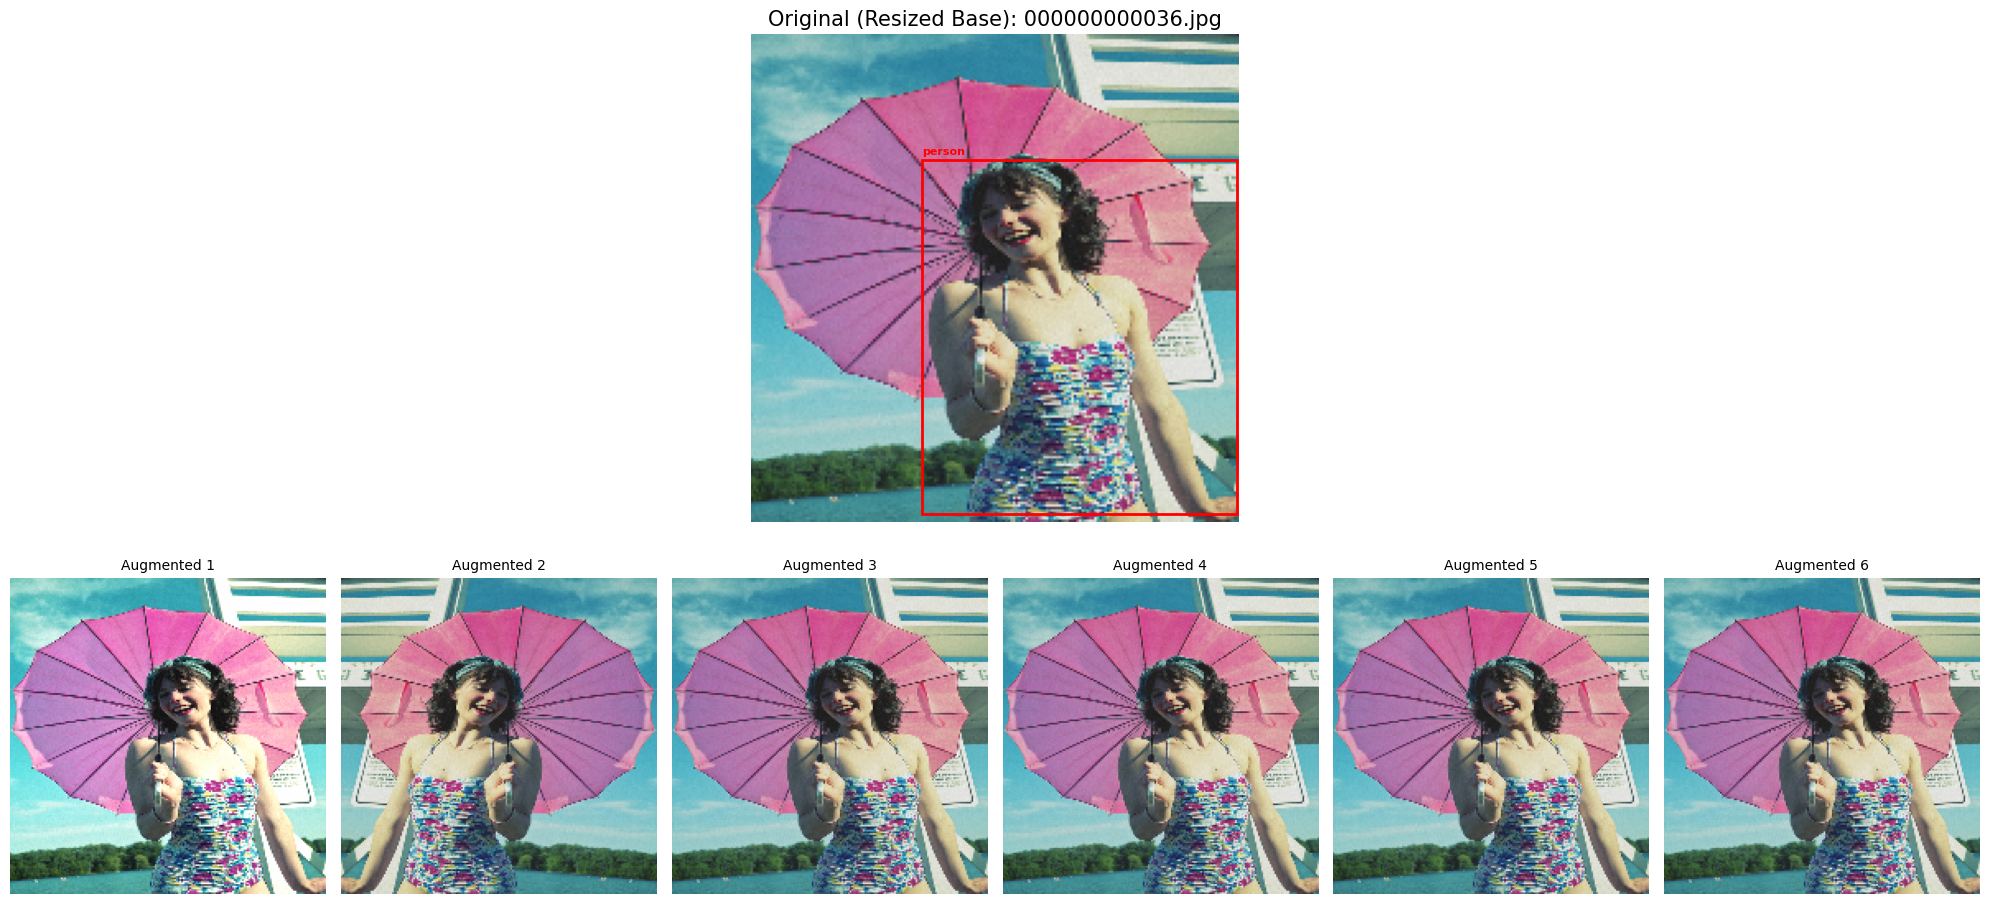

In [137]:
import matplotlib.patches as mpatches

def preview_augmentations(dataset, transform=None, index=0, n_samples=4):
    """
    Displays the baseline 'Original' image (resized/normalized) and
    several augmented versions with their respective bounding boxes.
    """
    if transform is None:
        transform = dataset.transform

    # Access the raw image and metadata
    img_id = dataset.image_ids[index]
    img_info = dataset.coco.loadImgs(img_id)[0]
    img_path = dataset.image_dir / img_info['file_name']

    image = cv2.imread(str(img_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Get original bboxes for this image
    ann_ids = dataset.coco.getAnnIds(imgIds=img_id, catIds=dataset.target_cat_ids)
    anns = dataset.coco.loadAnns(ann_ids)
    bboxes = [ann['bbox'] for ann in anns if ann['bbox'][2] > 0 and ann['bbox'][3] > 0]
    category_ids = [ann['category_id'] for ann in anns]

    # Helper for denormalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    # Class colors for visualization
    colors = {1: 'red', 2: 'yellow', 3: 'cyan', 4: 'magenta', 5: 'green'}
    class_names = ['background', 'person', 'sports_ball', 'chair', 'couch', 'dining_table']

    plt.figure(figsize=(20, 10))

    # Prepare and Plot Original
    # We use val_transform to get the 96x96 version the model actually sees
    # Note: val_transform is assumed to be defined globally as per your notebook
    base_data = val_transform(image=image, bboxes=bboxes, category_ids=category_ids)
    base_img = base_data['image'].permute(1, 2, 0).cpu().numpy()
    base_img = np.clip((base_img * std) + mean, 0, 1)

    ax_orig = plt.subplot(2, 1, 1)
    ax_orig.imshow(base_img)
    ax_orig.set_title(f"Original (Resized Base): {img_info['file_name']}", fontsize=15)
    ax_orig.axis('off')

    # Draw boxes on Original
    for box, cat_id in zip(base_data['bboxes'], base_data['category_ids']):
        x, y, w, h = box
        fomo_idx = dataset.coco_to_fomo.get(cat_id)
        color = colors.get(fomo_idx, 'white')
        rect = mpatches.Rectangle((x, y), w, h, linewidth=2, edgecolor=color, facecolor='none')
        ax_orig.add_patch(rect)
        ax_orig.text(x, y-2, class_names[fomo_idx], color=color, fontsize=8, fontweight='bold')

    # Plot Augmented Samples
    for i in range(n_samples):
        # Apply the stochastic transform (train_transform)
        augmented = transform(image=image, bboxes=bboxes, category_ids=category_ids)
        aug_img = augmented['image'].permute(1, 2, 0).cpu().numpy()
        aug_img = np.clip((aug_img * std) + mean, 0, 1)

        ax_aug = plt.subplot(2, n_samples, n_samples + i + 1)
        ax_aug.imshow(aug_img)
        ax_aug.set_title(f"Augmented {i+1}", fontsize=10)
        ax_aug.axis('off')

    plt.tight_layout()
    plt.show()

preview_augmentations(train_dataset, index=0, n_samples=6)

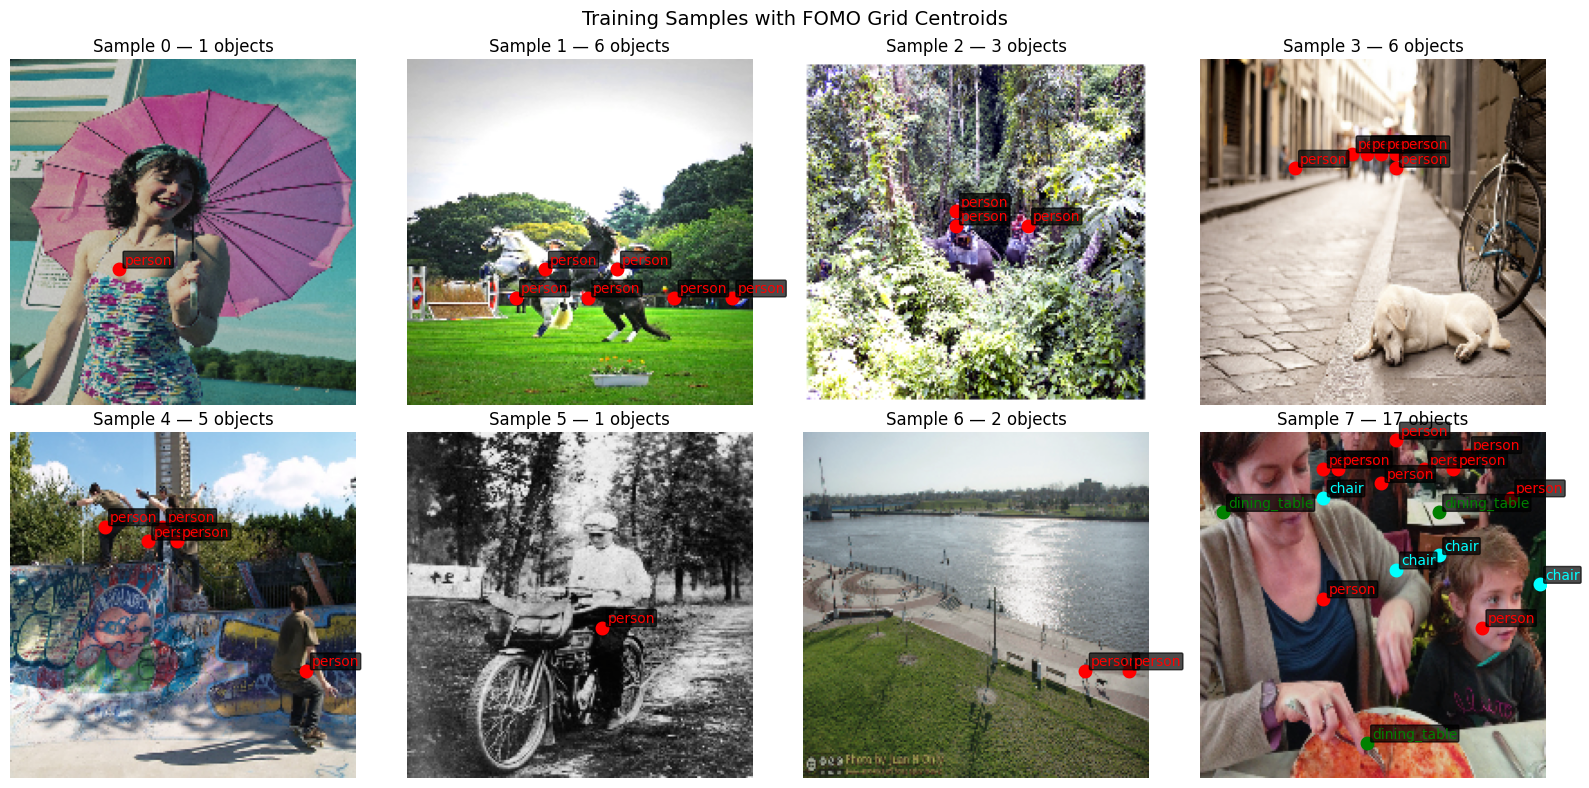

In [138]:
# ── Visualize a few training samples ─────────────────────────────────────

def denormalize(tensor, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    """Reverse ImageNet normalization for display."""
    img = tensor.clone()
    for c in range(3):
        img[c] = img[c] * std[c] + mean[c]
    return img.clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, ax in enumerate(axes.flat):
    img, target = train_dataset[i]
    img_display = denormalize(img).permute(1, 2, 0).numpy()

    ax.imshow(img_display)

    # Overlay grid cells with detections
    for gy in range(GRID_SIZE):
        for gx in range(GRID_SIZE):
            cls = target[gy, gx].item()
            if cls > 0:
                # Draw a marker at the cell center
                px = (gx + 0.5) * CELL_SIZE
                py = (gy + 0.5) * CELL_SIZE
                colors = ['', 'red', 'yellow', 'cyan', 'magenta', 'green']
                ax.plot(px, py, 'o', color=colors[cls], markersize=8, markeredgewidth=2)
                ax.text(px + 3, py - 3, FOMO_CLASS_NAMES[cls],
                        fontsize=10, color=colors[cls],
                        bbox=dict(boxstyle='round,pad=0.1', facecolor='black', alpha=0.7))

    obj_count = (target > 0).sum().item()
    ax.set_title(f'Sample {i} — {obj_count} objects')
    ax.axis('off')

plt.suptitle('Training Samples with FOMO Grid Centroids', fontsize=14)
plt.tight_layout()
plt.show()

## 6. FOMO Model Architecture

### Didactic: Building FOMO from Scratch

FOMO's architecture is elegant in its simplicity:

```
Input [B, 3, 96, 96]
       │
       ▼
┌──────────────────┐
│  MobileNetV2     │   Pretrained backbone, truncated at stride-8
│  features[:7]    │   Output: [B, 32, 12, 12]
└──────────────────┘
       │
       ▼
┌──────────────────┐
│  1×1 Conv (32→16)│   Reduce channels
│  BatchNorm + ReLU│
└──────────────────┘
       │
       ▼
┌──────────────────┐
│  1×1 Conv (16→6) │   Predict class per cell
└──────────────────┘
       │
       ▼
Output [B, 6, 12, 12]   Per-cell class logits
```

**Why MobileNetV2 features[:7]?**

MobileNetV2 has 19 feature blocks (features[0..18]). For a 96×96 input:

| Layer Range | Output Shape | Stride | Notes |
|-------------|-------------|--------|-------|
| features[0] | 48×48×32 | 2 | Initial conv |
| features[1] | 48×48×16 | 2 | First bottleneck |
| features[2:4] | 24×24×24 | 4 | |
| features[4:7] | **12×12×32** | **8** | ← We cut here |
| features[7:14] | 6×6×96 | 16 | Too low resolution |
| features[14:18] | 3×3×320 | 32 | Way too small |

Cutting at stride 8 gives us a 12×12 grid — each cell covers 8×8 pixels.
This is the sweet spot: enough resolution for centroid detection,
small enough for ESP32.

In [139]:
class FOMOModel(nn.Module):
    """
    FOMO: Faster Objects, More Objects

    A centroid-based object detector designed for microcontrollers.
    Uses a truncated MobileNetV2 backbone with a lightweight classification head.

    Args:
        num_classes: Total classes INCLUDING background (default=6)
        backbone_cutoff: Where to truncate MobileNetV2 features (default=7)
        dropout: Dropout rate before final conv (default=0.1)
    """

    def __init__(self, num_classes=NUM_CLASSES, backbone_cutoff=7, dropout=0.1, width_mult=1.0, round_nearest=8):
        super().__init__()

        # Load pretrained MobileNetV2 and truncate
        weights = MobileNet_V2_Weights.IMAGENET1K_V1 if width_mult == 1.0 else None
        full_backbone = mobilenet_v2(weights=weights, width_mult=width_mult, round_nearest=round_nearest)
        self.backbone = nn.Sequential(*list(full_backbone.features[:backbone_cutoff]))

        # Determine backbone output channels by doing a dummy forward pass
        with torch.no_grad():
            dummy = torch.zeros(1, 3, INPUT_SIZE, INPUT_SIZE)
            backbone_out = self.backbone(dummy)
            backbone_channels = backbone_out.shape[1]
            spatial = backbone_out.shape[2]
        print(f'Backbone output: {backbone_channels}ch × {spatial}×{spatial}')

        # Classification head: two 1×1 convolutions
        self.head = nn.Sequential(
            nn.Conv2d(backbone_channels, 16, kernel_size=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU6(inplace=True),
            nn.Dropout2d(p=dropout),
            nn.Conv2d(16, num_classes, kernel_size=1),
        )

        # Freeze early backbone layers (first 3 blocks) for faster convergence
        for i, layer in enumerate(self.backbone):
            if i < 3:
                for param in layer.parameters():
                    param.requires_grad = False

    def forward(self, x):
        """Forward pass.

        Args:
            x: [B, 3, 96, 96] input images (normalized)

        Returns:
            logits: [B, num_classes, 12, 12] per-cell class logits
        """
        features = self.backbone(x)
        logits = self.head(features)
        return logits

    def predict(self, x, conf_threshold=0.5):
        """Run inference and return detections.

        Returns list of (class_id, grid_x, grid_y, confidence) tuples.
        """
        self.eval()
        with torch.no_grad():
            logits = self.forward(x)                # [B, C, H, W]
            probs = F.softmax(logits, dim=1)        # [B, C, H, W]

            detections = []
            for b in range(x.shape[0]):
                batch_dets = []
                conf, pred_class = probs[b].max(dim=0)  # [H, W] each

                for gy in range(pred_class.shape[0]):
                    for gx in range(pred_class.shape[1]):
                        cls = pred_class[gy, gx].item()
                        c = conf[gy, gx].item()
                        if cls > 0 and c >= conf_threshold:
                            batch_dets.append((cls, gx, gy, c))
                detections.append(batch_dets)

            return detections


# ── Instantiate ──────────────────────────────────────────────────────────
model = FOMOModel(num_classes=NUM_CLASSES).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'Frozen parameters:    {total_params - trainable_params:,}')

Backbone output: 32ch × 24×24
Total parameters:     56,134
Trainable parameters: 49,174
Frozen parameters:    6,960


## 7. Training Loop

### Loss Function

FOMO uses **weighted cross-entropy** per grid cell. The weighting is critical
because ~95% of cells are background — without it, the model would just
predict background everywhere.

We compute class weights inversely proportional to frequency, then apply
a focal-loss-inspired modulation to further focus on hard examples.

In [140]:
def compute_class_frequency(dataloader, num_classes, num_batches=50):
    counts = torch.zeros(num_classes).to(DEVICE)
    total_cells = 0

    for i, (_, targets) in enumerate(dataloader):
        if i >= num_batches:
            break
        for cls in range(num_classes):
            counts[cls] += (targets == cls).sum().item()
        total_cells += targets.numel()

    freq = counts / total_cells
    return freq

class_freq = compute_class_frequency(train_loader, NUM_CLASSES).to(DEVICE)

In [141]:
def compute_weights_inverse(freq):
    return 1.0 / (freq + 1e-6)

def compute_weights_sqrt(freq):
    return 1.0 / (torch.sqrt(freq) + 1e-6)

def compute_weights_log(freq):
    return torch.log(1.0 / (freq + 1e-6) + 1.0)

def compute_weights_soft_inv(freq):
    return 1.0 / (torch.pow(freq, 0.65) + 1e-6)

def compute_weights_cb(freq, beta=0.999):
    """Class Balanced Loss: 1-beta / 1-beta^n"""
    effective_num = 1.0 - torch.pow(beta, freq)
    weights = (1.0 - beta) / (effective_num + 1e-6)
    return weights

def compute_weights_norm_log(freq):
    """Normalized Log: log(max_freq) / log(freq)"""
    max_f = torch.max(freq)
    weights = torch.log(max_f + 1.0) / torch.log(freq + 1.0)
    return weights

def get_weight_analysis(freq, names, num_classes):
    strategies = {
        "Inv": compute_weights_inverse,
        "SoftInv": compute_weights_soft_inv,
        "Sqrt": compute_weights_sqrt,
        "Log": compute_weights_log,
        "ClassBalanced_99": compute_weights_cb,
        # "NormLog": compute_weights_norm_log,
    }

    data = {
        # "Class Name": names,
        "Frequency": freq.cpu(),
    }

    for name, func in strategies.items():
        w = func(freq)
        # Normalization: Ensure mean(weights) * num_classes = total weight mass
        w = (w / w.sum()) * num_classes
        data[name] = w.cpu()

    return data

weight_strategies = get_weight_analysis(class_freq, FOMO_CLASS_NAMES, NUM_CLASSES)
df_weights = pd.DataFrame(weight_strategies)
print(df_weights.round(4))

class_weights = weight_strategies["SoftInv"].to(DEVICE)

   Frequency     Inv  SoftInv    Sqrt     Log  ClassBalanced_99
0     0.9929  0.0003   0.0057  0.0206  0.1071            0.0019
1     0.0056  0.0477   0.1657  0.2746  0.7979            0.2836
2     0.0001  2.9359   2.4282  2.1664  1.4307            1.6732
3     0.0009  0.2940   0.5408  0.6823  1.0770            0.9887
4     0.0001  1.9963   1.8855  1.7833  1.3714            1.6732
5     0.0004  0.7259   0.9741  1.0728  1.2159            1.3794


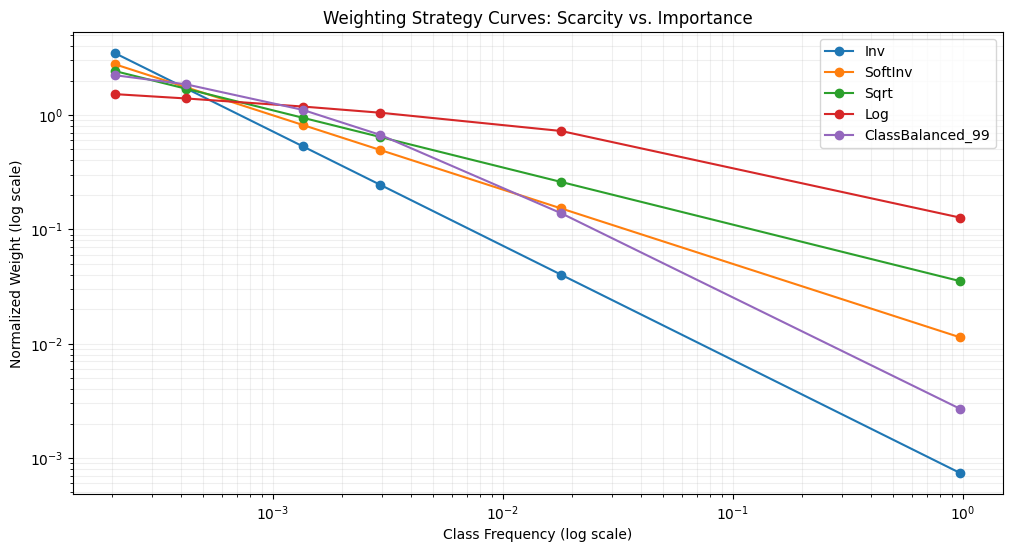

In [118]:
def plot_weight_curves(df_weights):
    plt.figure(figsize=(12, 6))

    # Sort by frequency for a clean line plot
    df_sorted = df_weights.sort_values(by="Frequency", ascending=False)

    strategy_cols = [c for c in df_sorted.columns if c != "Frequency"]

    for col in strategy_cols:
        plt.plot(df_sorted["Frequency"], df_sorted[col], marker='o', label=col.replace("Weight_", ""))

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel("Class Frequency (log scale)")
    plt.ylabel("Normalized Weight (log scale)")
    plt.title("Weighting Strategy Curves: Scarcity vs. Importance")
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()

plot_weight_curves(df_weights)

In [142]:
# ── Optimizer & Scheduler ────────────────────────────────────────────────
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

# Cosine annealing with warm restarts
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

# Weighted cross-entropy loss
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.10)

print('Optimizer: AdamW')
print(f'Initial LR: {LEARNING_RATE}')
print(f'Scheduler: CosineAnnealingWarmRestarts (T_0=10)')

Optimizer: AdamW
Initial LR: 0.001
Scheduler: CosineAnnealingWarmRestarts (T_0=10)


In [143]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    obj_correct = 0
    obj_total = 0

    for images, targets in loader:
        images = images.to(device)     # [B, 3, 96, 96]
        targets = targets.to(device)   # [B, 12, 12]

        logits = model(images)         # [B, 6, 12, 12]

        # CrossEntropyLoss expects [B, C, H, W] logits and [B, H, W] targets
        loss = criterion(logits, targets)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        # Accuracy stats
        preds = logits.argmax(dim=1)   # [B, 12, 12]
        correct += (preds == targets).sum().item()
        total += targets.numel()

        # Object-only accuracy (non-background cells)
        obj_mask = targets > 0
        if obj_mask.any():
            obj_correct += (preds[obj_mask] == targets[obj_mask]).sum().item()
            obj_total += obj_mask.sum().item()

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = correct / total
    epoch_obj_acc = obj_correct / max(obj_total, 1)

    return epoch_loss, epoch_acc, epoch_obj_acc


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    obj_correct = 0
    obj_total = 0

    # Per-class tracking
    class_tp = torch.zeros(NUM_CLASSES)
    class_fp = torch.zeros(NUM_CLASSES)
    class_fn = torch.zeros(NUM_CLASSES)

    for images, targets in loader:
        images = images.to(device)
        targets = targets.to(device)

        logits = model(images)
        loss = criterion(logits, targets)
        running_loss += loss.item() * images.size(0)

        preds = logits.argmax(dim=1)
        correct += (preds == targets).sum().item()
        total += targets.numel()

        obj_mask = targets > 0
        if obj_mask.any():
            obj_correct += (preds[obj_mask] == targets[obj_mask]).sum().item()
            obj_total += obj_mask.sum().item()

        # Per-class precision/recall
        for cls in range(1, NUM_CLASSES):
            pred_cls = (preds == cls)
            true_cls = (targets == cls)
            class_tp[cls] += (pred_cls & true_cls).sum().item()
            class_fp[cls] += (pred_cls & ~true_cls).sum().item()
            class_fn[cls] += (~pred_cls & true_cls).sum().item()

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = correct / total
    epoch_obj_acc = obj_correct / max(obj_total, 1)

    # F1 per class
    class_metrics = {}
    for cls in range(1, NUM_CLASSES):
        precision = class_tp[cls] / max(class_tp[cls] + class_fp[cls], 1)
        recall = class_tp[cls] / max(class_tp[cls] + class_fn[cls], 1)
        f1 = 2 * precision * recall / max(precision + recall, 1e-6)
        class_metrics[FOMO_CLASS_NAMES[cls]] = {
            'precision': precision.item(),
            'recall': recall.item(),
            'f1': f1.item()
        }

    return epoch_loss, epoch_acc, epoch_obj_acc, class_metrics

print('Training and validation functions ready.')

Training and validation functions ready.


In [145]:
# ── Main training loop ───────────────────────────────────────────────────

best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [],
           'train_obj_acc': [], 'val_obj_acc': [], 'lr': []}

for epoch in range(1, NUM_EPOCHS + 1):
    current_lr = optimizer.param_groups[0]['lr']

    # Train
    train_loss, train_acc, train_obj_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )

    # Validate
    val_loss, val_acc, val_obj_acc, class_metrics = validate(
        model, val_loader, criterion, DEVICE
    )

    scheduler.step()

    # Log
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['train_obj_acc'].append(train_obj_acc)
    history['val_obj_acc'].append(val_obj_acc)
    history['lr'].append(current_lr)

    print(f'Epoch {epoch:2d}/{NUM_EPOCHS}  '
          f'lr={current_lr:.6f}  '
          f'train_loss={train_loss:.4f}  '
          f'val_loss={val_loss:.4f}  '
          f'obj_acc={val_obj_acc:.3f}')

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_loss': val_loss,
            'val_obj_acc': val_obj_acc,
            'class_metrics': class_metrics,
        }, OUTPUT_DIR / 'fomo_best.pth')
        print(f'  ✓ Saved best model (val_loss={val_loss:.4f})')

    # Print per-class metrics every 5 epochs
    if epoch % 5 == 0 or True:
        print('  Per-class metrics:')
        for cls_name, m in class_metrics.items():
            print(f'    {cls_name:15s}: P={m["precision"]:.3f}  R={m["recall"]:.3f}  F1={m["f1"]:.3f}')

print('\nTraining complete!')

Epoch  1/30  lr=0.001000  train_loss=20.2855  val_loss=20.1403  obj_acc=0.058
  ✓ Saved best model (val_loss=20.1403)
  Per-class metrics:
    person         : P=0.387  R=0.060  F1=0.103
    sports_ball    : P=0.000  R=0.993  F1=0.000
    chair          : P=0.000  R=0.000  F1=0.000
    couch          : P=0.000  R=0.000  F1=0.000
    dining_table   : P=0.000  R=0.000  F1=0.000
Epoch  2/30  lr=0.000976  train_loss=20.2709  val_loss=20.1339  obj_acc=0.067
  ✓ Saved best model (val_loss=20.1339)
  Per-class metrics:
    person         : P=0.437  R=0.071  F1=0.122
    sports_ball    : P=0.000  R=1.000  F1=0.000
    chair          : P=0.000  R=0.000  F1=0.000
    couch          : P=0.000  R=0.000  F1=0.000
    dining_table   : P=0.000  R=0.000  F1=0.000
Epoch  3/30  lr=0.000905  train_loss=20.2567  val_loss=20.1300  obj_acc=0.062
  ✓ Saved best model (val_loss=20.1300)
  Per-class metrics:
    person         : P=0.494  R=0.064  F1=0.114
    sports_ball    : P=0.000  R=1.000  F1=0.000
    cha

KeyboardInterrupt: 

In [59]:
import copy

# Assuming weight_strategies = {"Inverse": weights1, "Sqrt": weights2, "Log": weights3}
all_run_histories = {}

for name, weights in weight_strategies.items():
    if name == "Frequency":
        continue

    print(f"\n{ '█'*20 } STARTING STRATEGY: {name} { '█'*20 }")

    # 1. Reset Model, Optimizer, and Scheduler for a fair test
    model = FOMOModel().to(DEVICE)
    weights = weights.to(DEVICE)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                  lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)
    criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.15)

    # 2. Expanded History Tracking
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_obj_acc': [], 'val_obj_acc': [],
        'lr': [],
        'class_metrics': [] # Will store the dict of P, R, F1 per epoch
    }

    best_val_loss = float('inf')

    for epoch in range(1, 4):
        current_lr = optimizer.param_groups[0]['lr']

        # Train & Validate
        train_loss, train_acc, train_obj_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_acc, val_obj_acc, class_metrics = validate(model, val_loader, criterion, DEVICE)

        scheduler.step()

        # Save to History
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_obj_acc'].append(train_obj_acc)
        history['val_obj_acc'].append(val_obj_acc)
        history['lr'].append(current_lr)
        history['class_metrics'].append(class_metrics)

        # 3. Comprehensive Printing
        print(f"[{name}] Ep {epoch:02d} | LR: {current_lr:.6f} | "
              f"Loss: (T:{train_loss:.4f} V:{val_loss:.4f}) | "
              f"ObjAcc: (T:{train_obj_acc:.3f} V:{val_obj_acc:.3f})")

        # Detailed Per-Class Print
        print(f"    {'Class':<15} | {'P':<6} | {'R':<6} | {'F1':<6}")
        print(f"    {'-'*35}")
        for cls_name, m in class_metrics.items():
            print(f"    {cls_name:<15} | {m['precision']:.3f} | {m['recall']:.3f} | {m['f1']:.3f}")

        # Save Best Model for this strategy
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_path = OUTPUT_DIR / f'fomo_best_{name.lower()}.pth'
            torch.save({'model_state_dict': model.state_dict(), 'metrics': class_metrics}, save_path)
            print(f"    ✓ New best {name} model saved.")

    all_run_histories[name] = history


████████████████████ STARTING STRATEGY: Inv ████████████████████
Backbone output: 32ch × 12×12


KeyboardInterrupt: 

In [ ]:
# ── Plot training curves ─────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Object accuracy
axes[1].plot(history['train_obj_acc'], label='Train obj acc')
axes[1].plot(history['val_obj_acc'], label='Val obj acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Object Cell Accuracy (non-background)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning rate
axes[2].plot(history['lr'])
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('LR Schedule')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150)
plt.show()

## 8. Evaluation & Visualization

In [ ]:
# ── Load best model and visualize predictions ────────────────────────────

checkpoint = torch.load(OUTPUT_DIR / 'fomo_best.pth', map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'Loaded best model from epoch {checkpoint["epoch"]}')
print(f'Val loss: {checkpoint["val_loss"]:.4f}')
print(f'Val object accuracy: {checkpoint["val_obj_acc"]:.3f}')
print('\nPer-class metrics:')
for cls_name, m in checkpoint['class_metrics'].items():
    print(f'  {cls_name:15s}: P={m["precision"]:.3f}  R={m["recall"]:.3f}  F1={m["f1"]:.3f}')

Loaded best model from epoch 10
Val loss: 0.3324
Val object accuracy: 0.307

Per-class metrics:
  person         : P=0.278  R=0.392  F1=0.325
  sports_ball    : P=0.214  R=0.338  F1=0.262
  chair          : P=0.364  R=0.006  F1=0.011
  couch          : P=0.000  R=0.000  F1=0.000
  dining_table   : P=0.000  R=0.000  F1=0.000


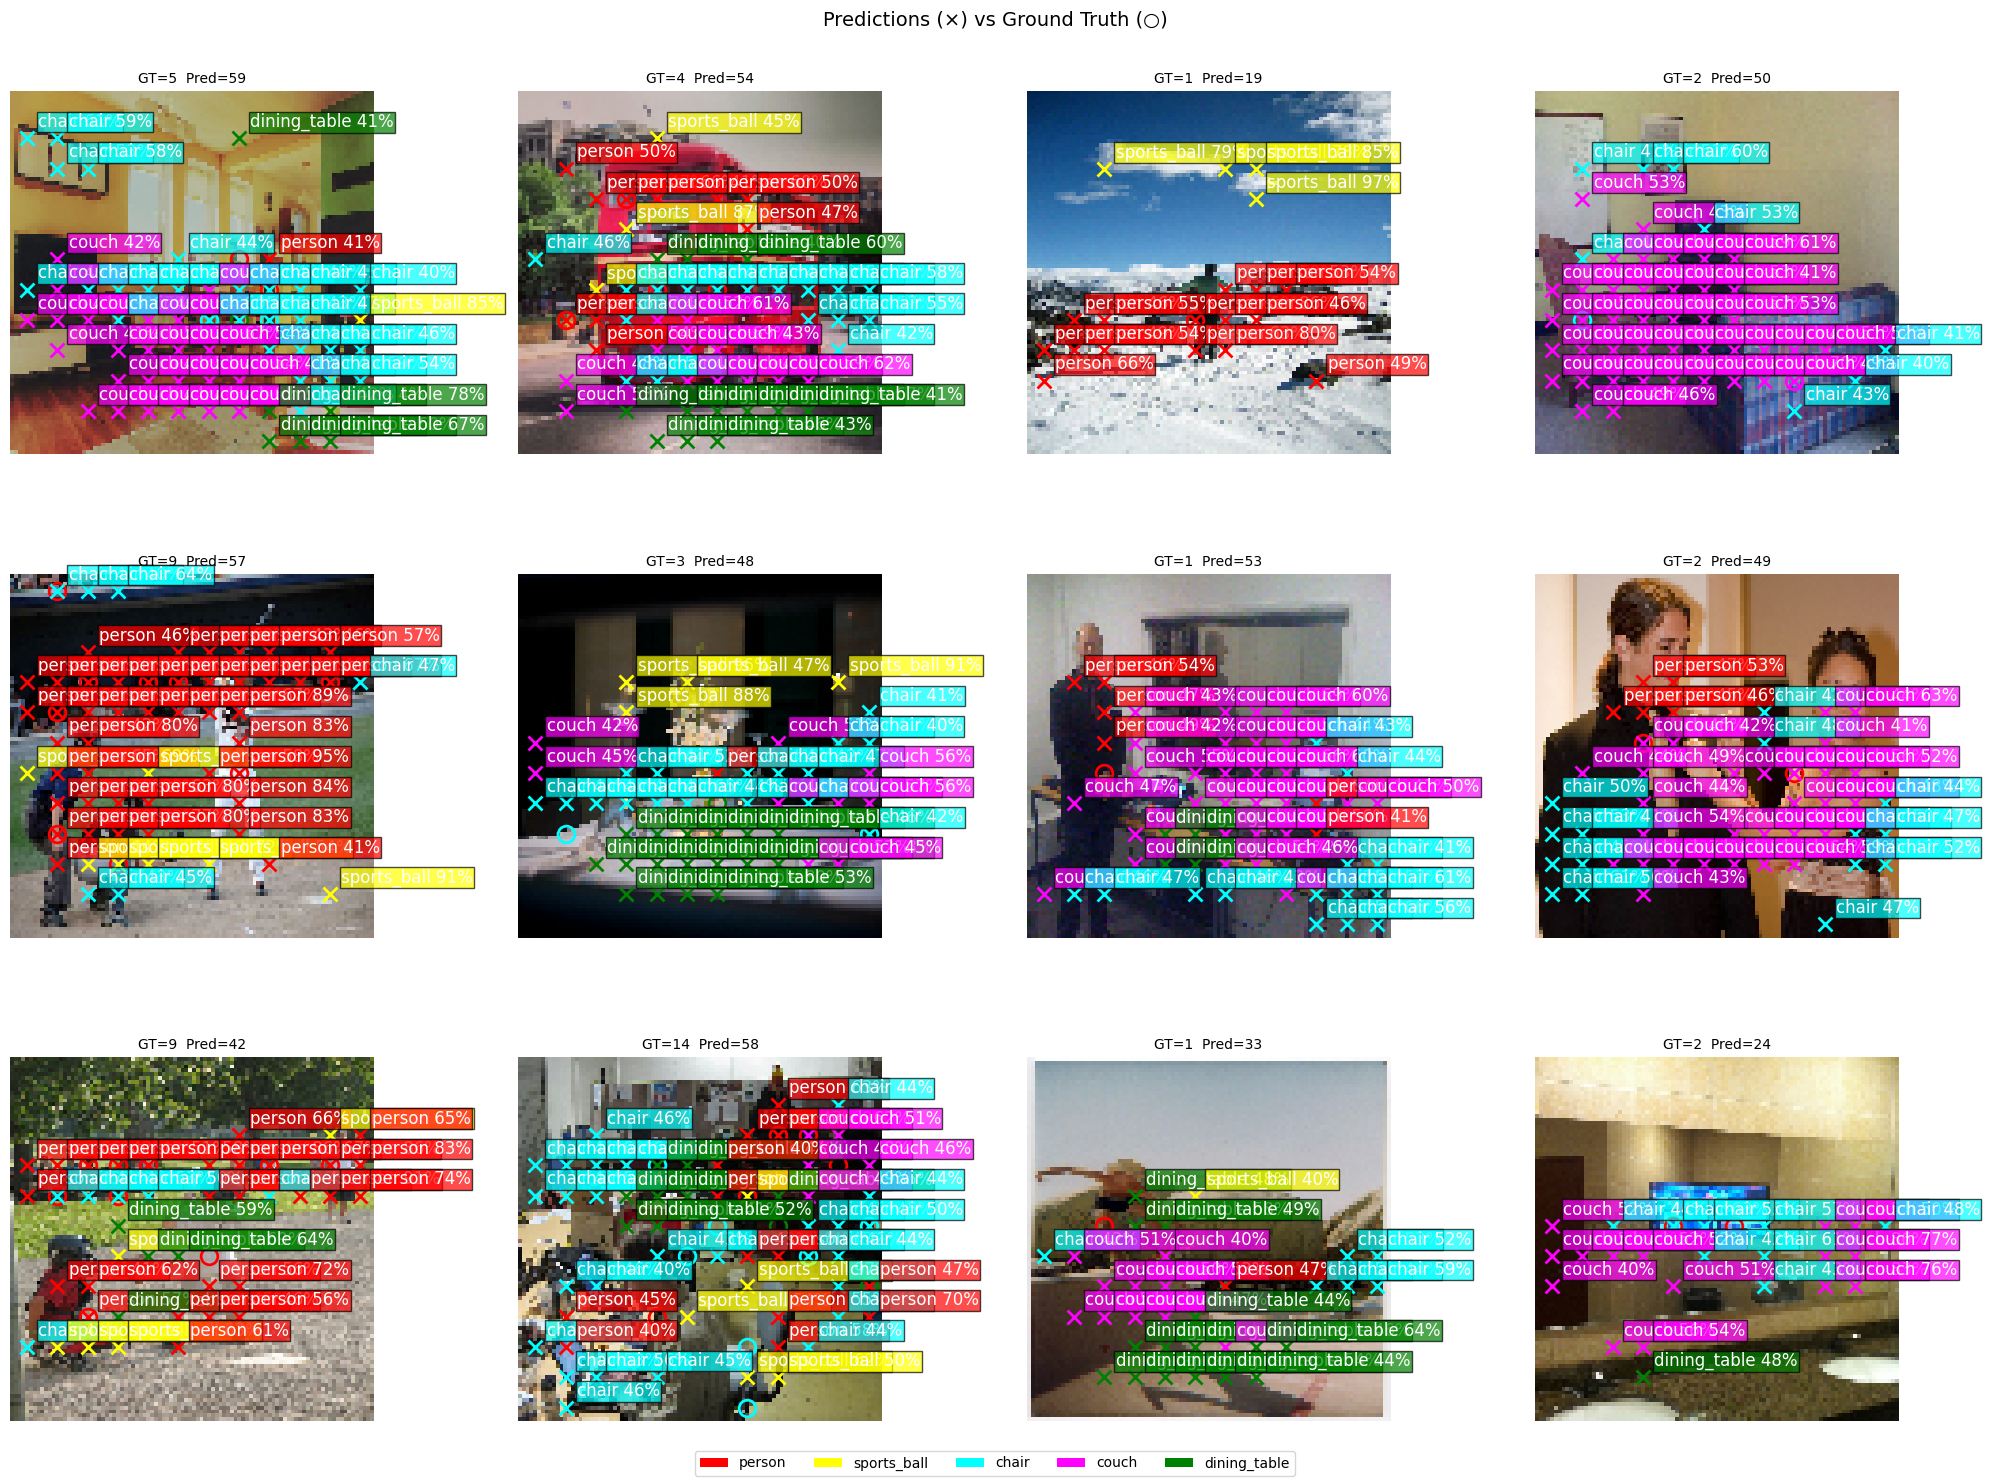

In [ ]:
# ── Visualize predictions on validation set ──────────────────────────────

model.eval()
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
colors = {1: 'red', 2: 'yellow', 3: 'cyan', 4: 'magenta', 5: 'green'}

for i, ax in enumerate(axes.flat):
    img, target = val_dataset[i * 10]  # Sample every 10th image
    img_tensor = img.unsqueeze(0).to(DEVICE)

    # Get predictions
    detections = model.predict(img_tensor, conf_threshold=0.4)[0]

    # Display
    img_display = denormalize(img).permute(1, 2, 0).numpy()
    ax.imshow(img_display)

    # Draw ground truth (circles)
    for gy in range(GRID_SIZE):
        for gx in range(GRID_SIZE):
            cls = target[gy, gx].item()
            if cls > 0:
                px = (gx + 0.5) * CELL_SIZE
                py = (gy + 0.5) * CELL_SIZE
                ax.plot(px, py, 'o', color=colors[cls], markersize=12,
                        markeredgewidth=2, fillstyle='none', label='GT')

    # Draw predictions (crosses)
    for cls, gx, gy, conf in detections:
        px = (gx + 0.5) * CELL_SIZE
        py = (gy + 0.5) * CELL_SIZE
        ax.plot(px, py, 'x', color=colors[cls], markersize=10, markeredgewidth=2)
        ax.text(px + 3, py - 3, f'{FOMO_CLASS_NAMES[cls]} {conf:.0%}',
                fontsize=12, color='white',
                bbox=dict(facecolor=colors[cls], alpha=0.7, pad=1))

    n_gt = (target > 0).sum().item()
    n_pred = len(detections)
    ax.set_title(f'GT={n_gt}  Pred={n_pred}', fontsize=10)
    ax.axis('off')

# Legend
legend_elements = [
    mpatches.Patch(facecolor=c, label=FOMO_CLASS_NAMES[i])
    for i, c in colors.items()
]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=10)

plt.suptitle('Predictions (×) vs Ground Truth (○)', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'val_predictions.png', dpi=150)
plt.show()

## 9. Export to TFLite (Int8 Quantized)

The export pipeline:
1. **PyTorch → ONNX** — standard export
2. **ONNX → TFLite** — using `onnx2tf`
3. **Quantization** — int8 weights + activations using representative dataset
4. **Validate model** - view model dimensions and size

Target: model file < 250 KB for ESP32 flash.

In [ ]:
# Step 1: Export to ONNX

model.eval()
model_cpu = model.to('cpu')

dummy_input = torch.randn(1, 3, INPUT_SIZE, INPUT_SIZE)
onnx_path = OUTPUT_DIR / 'fomo_model.onnx'

torch.onnx.export(
    model_cpu,
    dummy_input,
    str(onnx_path),
    opset_version=18,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes=None,  # Fixed batch size of 1 for MCU
)

onnx_size = onnx_path.stat().st_size / 1024
print(f'ONNX model saved: {onnx_path} ({onnx_size:.1f} KB)')

W0312 10:55:47.054000 323420 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0312 10:55:47.055000 323420 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0312 10:55:47.056000 323420 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0312 10:55:47.056000 323420 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `FOMOModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `FOMOModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 38 of general pattern rewrite rules.
ONNX model saved: output/fomo_model.onnx (89.6 KB)


In [ ]:
# Step 2: ONNX → TFLite with onnx2tf
# pip install onnx2tf tensorflow
import onnx2tf

tf_path = OUTPUT_DIR / "output_tf"
onnx2tf.convert(
    input_onnx_file_path=onnx_path,
    output_folder_path=tf_path,
    non_verbose=True,
)
# This produces a SavedModel in output_tf/

W0000 00:00:1773326960.129965  323420 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1773326960.129973  323420 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
W0000 00:00:1773326960.774687  323420 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1773326960.774697  323420 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


In [ ]:
# Step 3: Quantize with TFLite converter
import tensorflow as tf
import numpy as np

tflite_path = tf_path/"fomo_int8.tflite"
converter = tf.lite.TFLiteConverter.from_saved_model(str(tf_path))
converter.optimizations = [tf.lite.Optimize.DEFAULT]

def representative_dataset():
    for i in range(100):
        img, _ = val_dataset[i]
        # Must be numpy float32 in NHWC format after onnx2tf conversion
        img_np = img.unsqueeze(0).numpy()
        # Transpose NCHW -> NHWC if onnx2tf outputs NHWC signature
        img_np = np.transpose(img_np, (0, 2, 3, 1))
        yield [img_np]

converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

W0000 00:00:1773327194.079130  323420 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1773327194.079140  323420 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


In [ ]:
# Step 4: Verify the TFLite model

import tensorflow as tf

interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print('Input details:')
for d in input_details:
    print(f'  shape={d["shape"]}  dtype={d["dtype"]}  '
          f'quant={d.get("quantization_parameters", {})}')

print('\nOutput details:')
for d in output_details:
    print(f'  shape={d["shape"]}  dtype={d["dtype"]}  '
          f'quant={d.get("quantization_parameters", {})}')

# Report size
tflite_size = tflite_path.stat().st_size / 1024
print(f'\nTFLite model size: {tflite_size:.1f} KB')
if tflite_size < 250:
    print('✓ Fits in ESP32 flash budget (<250 KB)')
else:
    print('⚠ Model exceeds 250 KB — consider reducing backbone_cutoff or channels')

Input details:
  shape=[ 1 96 96  3]  dtype=<class 'numpy.int8'>  quant={'scales': array([0.01865845], dtype=float32), 'zero_points': array([-14], dtype=int32), 'quantized_dimension': 0}

Output details:
  shape=[ 1 12 12  6]  dtype=<class 'numpy.int8'>  quant={'scales': array([0.06796614], dtype=float32), 'zero_points': array([27], dtype=int32), 'quantized_dimension': 0}

TFLite model size: 111.7 KB
✓ Fits in ESP32 flash budget (<250 KB)


In [ ]:
# ── Test TFLite model accuracy ───────────────────────────────────────────

def run_tflite_inference(interpreter, image_np):
    """Run one inference on the TFLite model."""
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    # Quantize input if needed
    if input_details['dtype'] == np.int8:
        quant = input_details['quantization_parameters']
        scale = quant['scales'][0]
        zero_point = quant['zero_points'][0]
        image_quantized = (image_np / scale + zero_point).astype(np.int8)
        interpreter.set_tensor(input_details['index'], image_quantized)
    else:
        interpreter.set_tensor(input_details['index'], image_np.astype(np.float32))

    interpreter.invoke()
    output = interpreter.get_tensor(output_details['index'])

    # Dequantize output if needed
    if output_details['dtype'] == np.int8:
        quant = output_details['quantization_parameters']
        scale = quant['scales'][0]
        zero_point = quant['zero_points'][0]
        output = (output.astype(np.float32) - zero_point) * scale

    return output


# Compare PyTorch vs TFLite on 50 validation samples
model_cpu.eval()
match_count = 0
total_cells = 0

for i in range(50):
    img, target = val_dataset[i]
    img_np = img.unsqueeze(0).numpy()
    img_np = img_np.transpose((0,2,3,1)) # NCHW -> NHWC

    # PyTorch prediction
    with torch.no_grad():
        pt_logits = model_cpu(img.unsqueeze(0))
        pt_pred = pt_logits.argmax(dim=1).squeeze().numpy()

    # TFLite prediction
    tfl_logits = run_tflite_inference(interpreter, img_np)
    # Output may be [1, 6, 12, 12] or [1, 12, 12, 6] depending on converter
    if tfl_logits.shape[-1] == NUM_CLASSES:  # NHWC format
        tfl_pred = tfl_logits[0].argmax(axis=-1)
    else:  # NCHW format
        tfl_pred = tfl_logits[0].argmax(axis=0)

    match_count += (pt_pred == tfl_pred).sum()
    total_cells += pt_pred.size

agreement = match_count / total_cells
print(f'PyTorch ↔ TFLite agreement: {agreement:.1%}')

PyTorch ↔ TFLite agreement: 96.2%


## 10. Convert TFLite to C Header for ESP32

The final step: convert the `.tflite` file to a C byte array that
can be included in the ESP32 firmware.

This generates `fomo_model.h` which the Rust code includes via `include_bytes!()`.

In [ ]:
# ── Generate the model as a raw .tflite binary ───────────────────────────
# The Rust side will use include_bytes!() directly on the .tflite file.
# We also generate a C header as a fallback for C/C++ builds.

import shutil

# Copy the tflite model to the esp32 project directory
esp_model_dir = Path('esp32/model')
esp_model_dir.mkdir(parents=True, exist_ok=True)

dest = esp_model_dir / 'fomo_model_int8.tflite'
shutil.copy2(tflite_path, dest)

# Save model metadata
metadata = {
    'input_size': INPUT_SIZE,
    'grid_size': GRID_SIZE,
    'num_classes': NUM_CLASSES,
    'class_names': FOMO_CLASS_NAMES,
    'normalization': {
        'mean': [0.485, 0.456, 0.406],
        'std': [0.229, 0.224, 0.225],
    },
    'model_size_bytes': len(model_bytes),
}
with open(esp_model_dir / 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('All export artifacts ready for ESP32!')
print(f'  {dest}')
print(f'  {esp_model_dir / "model_metadata.json"}')

All export artifacts ready for ESP32!
  esp32/model/fomo_model_int8.tflite
  esp32/model/model_metadata.json
